### Scatter plots 
Relating the amount of fragmented replay in session or day t-1 to behavior changes in day t

In [1]:
%reload_ext autoreload
%autoreload 2

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import spikeinterface as si
import pynwb
import xarray as xr
import os
import pickle
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
import statsmodels.api as sm

In [3]:
from spyglass.shijiegu.Analysis_SGU import TrialChoice,RippleTimes,EpochPos,TrialChoiceReplayTransition
from spyglass.shijiegu.helpers import interval_union,interpolate_to_new_time
from spyglass.shijiegu.load import load_LFP,load_position
from spyglass.shijiegu.ripple_detection import (loadRippleLFP,ExtendInterSection,InterSection,
                                                plot_ripple,threshold_by_zscore_Gu,
                                                Kay_ripple_detector,Karlsson_ripple_detector,Gu_ripple_detector,multiunit_HSE_detector,
                                                removeDataBeforeTrial1,removeArtifactTime,
                                                loadRippleLFP_OneChannelPerElectrode,ripple_detection_master)
from spyglass.shijiegu.Analysis_SGU import (TetrodeNumber,MUA,ExtendedTrialChoiceReplay,ExtendedRippleTimes,RippleTimesWithDecode)
from spyglass.common.common_position import IntervalLinearizedPosition
from spyglass.common.common_task import TaskEpoch

[2025-11-21 12:04:28,573][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [4]:
from spyglass.shijiegu.pairwiseDecode import merge_overlapping_ranges,removeEmptyDecode
from spyglass.shijiegu.ripple_add_replay import remove_adjacent
from spyglass.shijiegu.pairwiseDecode import replay_transitions,behavior_transitions,findXCorrAllDays

from spyglass.shijiegu.fragmented_general import cont_vs_frag_occurrence_day

In [5]:
from spyglass.shijiegu.load import load_run_sessions

In [6]:
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.shijiegu.load import load_run_sessions
from spyglass.shijiegu.Analysis_SGU import RippleTimesWithDecode, TrialChoice
from spyglass.shijiegu.ripple_detection import removeDataBeforeTrial1

In [85]:
def get_behavior(animal, dates, behavior_datafolder):
    sequence_datapath = os.path.join(behavior_datafolder,animal,'behavior_metaSequence_'+animal+'.p')
    data_pair=pickle.load(open(os.path.join(behavior_datafolder,'behavior_correctPair_'+animal+'.p'), "rb"))
    #data_seqlen=pickle.load(open(os.path.join(datafolder,animal,'behavior_sequencelen_'+animal+'.p'), "rb"))
    
    with open(sequence_datapath, 'rb') as f:
        behavior_data = pickle.load(f)  
        
    total_trial_num = {}
    occurance_rates = {}
    pct_correct = {}
    #seq_len = {}
    seq_types = {}

    for day in dates:
        subset_ind = np.argwhere(behavior_data['dateIntAll'] == int(day)).ravel()
        
        total_trial_num_day = np.zeros(len(subset_ind))
        occurance_rates_day = np.zeros((len(subset_ind),6))
        pct_correct_day = np.zeros((len(subset_ind),6))
        seq_types_day = np.zeros(len(subset_ind))
        #seq_len_day = np.zeros(len(subset_ind))
        
        for n in range(len(subset_ind)):
    
            session_ind = subset_ind[n]
            total_trial_num_day[n] = len(behavior_data['outersAll'][session_ind])
            seq_types_day[n] = behavior_data['seqtype_int'][session_ind]
            #seq_len_day[n] = data_seqlen['mean'][session_ind]
            
            for seq in range(6):
                occurance_rates_day[n,seq] = np.mean(behavior_data['occurance_rates'][seq][session_ind])
                pct_correct_day[n,seq] = data_pair['pctCorrect'][session_ind][seq]
        
        total_trial_num[day] = total_trial_num_day
        occurance_rates[day] = occurance_rates_day
        seq_types[day] = seq_types_day
        pct_correct[day] = pct_correct_day
        #seq_len[day] = seq_len_day
        
    return total_trial_num, occurance_rates, seq_types, pct_correct

In [126]:
def return_scatter_plot_data(output_folder, animal, dates, behavior_datafolder):

    output_path = os.path.join(output_folder, f"{animal}_ripple_tally.pickle") #os.join(output_folder,plot_data_filename)
    with open(output_path, 'rb') as f:
        data = pickle.load(f)  

    sequence_datapath = os.path.join(behavior_datafolder,animal,'behavior_metaSequence_'+animal+'.p')
    data_pair=pickle.load(open(os.path.join(behavior_datafolder,'behavior_correctPair_'+animal+'.p'), "rb"))
    #data_seqlen=pickle.load(open(os.path.join(datafolder,animal,'behavior_sequencelen_'+animal+'.p'), "rb"))
    
    with open(sequence_datapath, 'rb') as f:
        behavior_data = pickle.load(f)  

    num_all, num_cont_all, num_frag_all = data["num_all"], data["num_cont_all"], data["num_frag_all"]
    pct_cont_all, pct_frag_all = data["pct_cont_all"], data["pct_frag_all"]
    time_cont_all, time_frag_all = data["time_cont_all"], data["time_frag_all"]
    
    total_trial_num, occurance_rates, seq_types, pct_correct = get_behavior(animal, dates, behavior_datafolder)
    
    time_cont_day = [np.mean(time_cont_all[d]) for d in dates]
    time_frag_day = [np.mean(time_frag_all[d]) for d in dates]
    
    num_cont_day = [np.mean(num_cont_all[d]) for d in dates]
    num_frag_day = [np.mean(num_frag_all[d]) for d in dates]
    
    pct_cont_day = [np.sum(num_cont_all[d])/num_all[d] for d in dates]
    pct_frag_day = [np.sum(num_frag_all[d])/num_all[d] for d in dates]
    
    occurance_rates_day = np.concatenate([np.mean(occurance_rates[d],axis = 0).reshape((1,6)) for d in dates])

    correct_seq_occurance_day = []
    pair_correct_pct_day = []
    #seq_len_day = []
    
    for d in dates:
        tmp = [] 
        #seq_len_tmp = [] #like tmp, but for seq_len
        
        total_trial_num = 0
        
        subset_ind = np.argwhere(behavior_data['dateIntAll'] == int(d)).ravel()
    
        
        for n in range(len(subset_ind)):
            session_ind = subset_ind[n]
            trial_num_session = len(behavior_data['outersAll'][session_ind])
            total_trial_num += trial_num_session
            seq_types_session = behavior_data['seqtype_int'][session_ind]
    
            #seq_len_tmp.append(data_seqlen['mean'][session_ind] * trial_num_session)
            
    
            tmp.append(np.mean(behavior_data['occurance_rates'][seq_types_session-1][session_ind]) * trial_num_session)
        
        correct_seq_occurance_day.append(np.sum(tmp)/total_trial_num * 100)
        #seq_len_day.append(np.sum(seq_len_tmp)/total_trial_num)
        
    pct_increase_day = 100 * np.diff(correct_seq_occurance_day)/(np.array(correct_seq_occurance_day[:-1]))
    pct_increase_day[np.isnan(pct_increase_day)] = 300
    pct_increase_day[np.isinf(pct_increase_day)] = 300
    
    pairwise_day = np.concatenate([np.mean(pct_correct[d],axis = 0).reshape((1,6)) for d in dates])

    ratio_day = np.array(time_frag_day)/(np.array(time_cont_day) + np.array(time_frag_day))
    ratio_day = ratio_day[:-1]

    return ratio_day, pct_increase_day

### which days to use

In [16]:
dates_to_plot = {}
encoding_sets = {}
classifier_param_names = {}
decode_threshold_methods = {}
behavior_datafolders = {}

In [63]:
output_folder = '/stelmo/shijie/fragmented_ripple/'

In [25]:
animal = 'Eliot'
dates_to_plot[animal] = ['20221017','20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
encoding_sets[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshold_methods[animal] = 'MUA_0SD'
behavior_datafolders[animal] ='/cumulus/shijie/behavior_pilot/Batch1'

animal = 'Lewis'
dates_to_plot[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshold_methods[animal] = 'MUA_M05SD'
behavior_datafolders[animal] = '/cumulus/shijie/behavior_pilot/Batch1'

animal = 'Molly'
dates_to_plot[animal] = ['20220416','20220417','20220418','20220419','20220420']
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshold_methods[animal] = 'MUA_M05SD'
behavior_datafolders[animal] ='/stelmo/shijie/behavior_pilot/Batch1'

animal = 'Julio'
dates_to_plot[animal] = ['20230801','20230802','20230803','20230804','20230805',
                 '20230806','20230807','20230808','20230809','20230810','20230811'
                ]
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshold_methods[animal] = 'MUA_0SD'
behavior_datafolders[animal] ='/cumulus/shijie/behavior_pilot/Batch1'

animal = 'Klein'
dates_to_plot[animal] = ['20231101','20231102','20231103','20231104','20231105','20231106','20231107','20231108',
                 '20231109','20231111','20231112','20231113','20231114'
                ]
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshold_methods[animal] = 'MUA_0SD'
behavior_datafolders[animal] ='/cumulus/shijie/behavior_pilot/Batch1'

In [80]:
for animal in ['Lewis']:#'Julio', 'Klein', 'Lewis', 'Eliot']:
    statescript_threshold = 30
    if animal.lower() == "julio":
        statescript_threshold = 42
    
    (num_all, 
     num_cont_all, num_frag_all, 
     pct_cont_all, pct_frag_all, 
     time_cont_all, time_frag_all) = cont_vs_frag_occurrence_day(animal,dates_to_plot[animal],
                                                                 encoding_sets[animal],
                                                                 classifier_param_names[animal],
                                                                 decode_threshold_methods[animal],
                                                                 statescript_threshold = statescript_threshold)
    
    data = {"num_all": num_all,
            "num_cont_all":num_cont_all, "num_frag_all":num_frag_all,
            "pct_cont_all":pct_cont_all, "pct_frag_all":pct_frag_all,
            "time_cont_all": time_cont_all, "time_frag_all":time_frag_all}
    
    output_path = os.path.join(output_folder, f"{animal}_ripple_tally.pickle") #os.join(output_folder,plot_data_filename)
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved.")

[2025-11-21 13:27:01,026][WARNING]: Skipped checksum for file with hash: ea6cd873-b201-493c-a94d-fed75f11452b, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_6I8GMYQA5R.nwb
[2025-11-21 13:27:01,051][WARNING]: Skipped checksum for file with hash: ea6cd873-b201-493c-a94d-fed75f11452b, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_6I8GMYQA5R.nwb
[2025-11-21 13:27:01,058][WARNING]: Skipped checksum for file with hash: ea6cd873-b201-493c-a94d-fed75f11452b, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_6I8GMYQA5R.nwb


*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
lewis20240105_ 1         01_Rev2Sleep1  pos 0 valid ti
lewis20240105_ 2         02_Rev2Session pos 1 valid ti
lewis20240105_ 3         03_Rev2Sleep2  pos 2 valid ti
lewis20240105_ 4         04_Rev2Session pos 3 valid ti
lewis20240105_ 5         05_Rev2Sleep3  pos 4 valid ti
lewis20240105_ 6         06_Rev2Session pos 5 valid ti
lewis20240105_ 7         07_Rev2Sleep4  pos 6 valid ti
lewis20240105_ 8         08_Rev2Session pos 7 valid ti
lewis20240105_ 9         09_Rev2Sleep5  pos 8 valid ti
lewis20240105_ 10        10_Rev2Session pos 9 valid ti
 (Total: 10)

immobile time is  1077.9269025325775 seconds.


[2025-11-21 13:27:01,268][WARNING]: Skipped checksum for file with hash: 7a036ab2-504c-05b4-13da-8fb287247b1f, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_IGTJYN9ZHT.nwb
[2025-11-21 13:27:01,293][WARNING]: Skipped checksum for file with hash: 7a036ab2-504c-05b4-13da-8fb287247b1f, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_IGTJYN9ZHT.nwb
[2025-11-21 13:27:01,300][WARNING]: Skipped checksum for file with hash: 7a036ab2-504c-05b4-13da-8fb287247b1f, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_IGTJYN9ZHT.nwb
[2025-11-21 13:27:01,486][WARNING]: Skipped checksum for file with hash: 9408cb38-08e6-3400-d190-8afc0a4965fb, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_JF4F19EIHC.nwb
[2025-11-21 13:27:01,512][WARNING]: Skipped checksum for file with hash: 9408cb38-08e6-3400-d190-8afc0a4965fb, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_JF4F19EIHC.nwb


immobile time is  778.3257660865784 seconds.


[2025-11-21 13:27:01,519][WARNING]: Skipped checksum for file with hash: 9408cb38-08e6-3400-d190-8afc0a4965fb, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_JF4F19EIHC.nwb
[2025-11-21 13:27:01,699][WARNING]: Skipped checksum for file with hash: 913869fd-03e5-fbdd-ac25-029dde8485b4, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_8VODKZ32UD.nwb
[2025-11-21 13:27:01,714][WARNING]: Skipped checksum for file with hash: 913869fd-03e5-fbdd-ac25-029dde8485b4, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_8VODKZ32UD.nwb
[2025-11-21 13:27:01,717][WARNING]: Skipped checksum for file with hash: 913869fd-03e5-fbdd-ac25-029dde8485b4, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_8VODKZ32UD.nwb


...

immobile time is  782.0395176410675 seconds.
immobile time is  823.3818621635437 seconds.


[2025-11-21 13:27:05,543][WARNING]: Skipped checksum for file with hash: 9c7b9599-4d12-0a40-832e-99fcad1e749e, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_2WDVU84FFI.nwb
[2025-11-21 13:27:05,558][WARNING]: Skipped checksum for file with hash: 9c7b9599-4d12-0a40-832e-99fcad1e749e, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_2WDVU84FFI.nwb
[2025-11-21 13:27:05,562][WARNING]: Skipped checksum for file with hash: 9c7b9599-4d12-0a40-832e-99fcad1e749e, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_2WDVU84FFI.nwb
[2025-11-21 13:27:05,682][WARNING]: Skipped checksum for file with hash: ede56986-c16c-d4ff-a322-a7f928703155, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_1SUPK45O49.nwb
[2025-11-21 13:27:05,698][WARNING]: Skipped checksum for file with hash: ede56986-c16c-d4ff-a322-a7f928703155, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_1SUPK45O49.nwb
[2025-11-21 13:27:05,701][WARNING]: Skipped checksum for file with hash: ed

immobile time is  754.8994295597076 seconds.
immobile time is  369.5116868019104 seconds.


[2025-11-21 13:27:05,776][WARNING]: Skipped checksum for file with hash: c8169409-cf41-a09d-04e2-5cc586885935, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_2Q23WZ9H5D.nwb
[2025-11-21 13:27:05,779][WARNING]: Skipped checksum for file with hash: c8169409-cf41-a09d-04e2-5cc586885935, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_2Q23WZ9H5D.nwb


immobile time is  342.53496742248535 seconds.
Data successfully pickled and saved.


In [127]:
### behavior 
pct_increase_day_all = {}
ratio_day_all = {}

for animal in ['Julio', 'Klein', 'Lewis', 'Eliot','Molly']:
    
    dates = dates_to_plot[animal]
    behavior_datafolder = behavior_datafolders[animal]
    
    ratio_day_all[animal], pct_increase_day_all[animal] = return_scatter_plot_data(
        output_folder, animal, dates, behavior_datafolder)
    

In [128]:
# plotting and regression

Regression Results Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.120
Method:                 Least Squares   F-statistic:                   0.03911
Date:                Fri, 21 Nov 2025   Prob (F-statistic):              0.848
Time:                        13:46:21   Log-Likelihood:                -63.366
No. Observations:                  10   AIC:                             130.7
Df Residuals:                       8   BIC:                             131.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7826   

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n

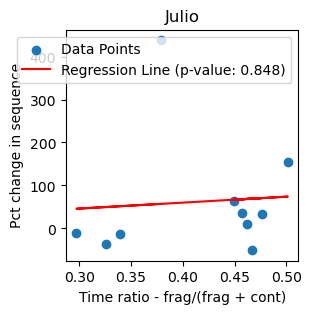

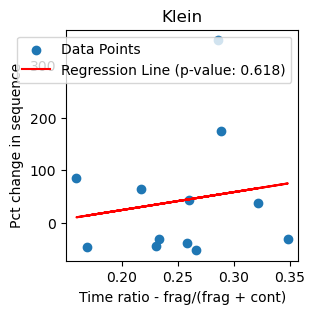

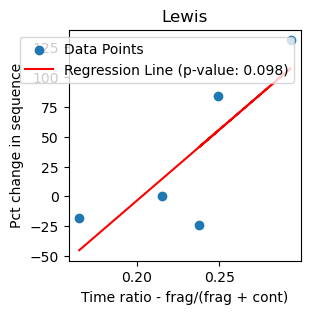

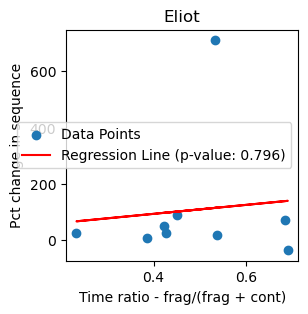

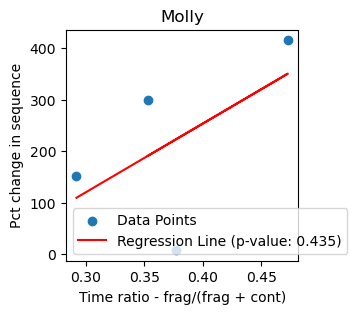

In [129]:
for animal in ['Julio', 'Klein', 'Lewis', 'Eliot','Molly']:
    X = ratio_day_all[animal]
    
    y = pct_increase_day_all[animal]
    
    X = sm.add_constant(X)
    
    # 3. Fit the OLS (Ordinary Least Squares) linear regression model
    model = sm.OLS(y, X)
    results = model.fit()
    
    # 4. Print the summary of the regression results to get the p-value
    print("Regression Results Summary:")
    print(results.summary())
    
    # 5. Extract the predicted values and the p-value for the independent variable
    y_pred = results.predict(X)
    # The p-value for the independent variable (excluding the constant)
    # is usually at index 1 in the pvalues array for simple linear regression.
    p_value_X = results.pvalues[1] 
    
    # 6. Plot the data and the regression line
    plt.figure(figsize=(3, 3))
    plt.scatter(X[:, 1], y, label='Data Points') # X[:, 1] to get the original X values
    plt.plot(X[:, 1], y_pred, color='red', label=f'Regression Line (p-value: {p_value_X:.3f})')
    plt.xlabel('Time ratio - frag/(frag + cont)')
    plt.ylabel('Pct change in sequence')
    plt.title(f'{animal}')
    plt.legend()

### Mixed linear effect

In [130]:
animals = ['Julio', 'Klein', 'Lewis', 'Eliot','Molly']

GLM_xy = []
for animal in animals:
    dates = dates_to_plot[animal]
    behavior_datafolder = behavior_datafolders[animal]
    
    ratio_day, pct_increase_day = return_scatter_plot_data(
        output_folder, animal, dates, behavior_datafolder)


    animal_category = [a == animal for a in animals]
    for ind in range(len(ratio_day)):
        GLM_xy.append(animal_category + [
            ratio_day[ind],
            pct_increase_day[ind]])

GLM_xy = np.array(GLM_xy)

In [131]:
GLM_xy.shape

(40, 7)

In [134]:
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_xy[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["fragmented proportion"] = GLM_xy[:,len(animals)]

X = pd.DataFrame(feature_dict)
#X = sm.add_constant(X)
y = GLM_xy[:,-1]

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result1 = ols_model.fit()

print("Mixed Linear Effect \n",ols_result1.summary())


Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     1.082
Date:                Fri, 21 Nov 2025   Prob (F-statistic):              0.388
Time:                        13:49:19   Log-Likelihood:                -256.15
No. Observations:                  40   AIC:                             524.3
Df Residuals:                      34   BIC:                             534.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Rat J   